In [2]:
import numpy as np
from scipy.optimize import minimize
from IPython.display import clear_output
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

rc = {"font.family" : "Times New Roman", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)

from QAOA import *
from hamiltonians import *
from heuristics import *
from visualization import *
from analysis import *

import warnings
warnings.filterwarnings("ignore")

In [3]:
def get_avg_singular(n,p_max,n_instances,path,fdata):
    
    # ions chain parameters
    nu_rad = 1e6
    nu_ax = 0.15e6
    mu = 2*np.pi*(nu_rad + 10e3) # in Hz
    Omega_max = 2*np.pi*30e3     # in Hz

    path = path + str(n)+ 'q/'

    coupling_mat = radial_coupling_matrix(n, nu_rad, nu_ax, mu, Omega_max) # in kHz
    
    d = 2*p_max    
    
    S = np.zeros((p_max,n_instances))

    for index in range(1,n_instances+1):

        fname = str(n) + fdata + str(index) + '.txt'

        A = np.genfromtxt(path+fname,skip_header=2,skip_footer=2*p_max)
        angles = np.genfromtxt(path+fname,skip_header=3+2*p_max-1)
        weights = list(np.genfromtxt(path+fname,skip_header=1,skip_footer=2*p_max+1))

        H1 = ion_native_hamiltonian(n,A,coupling_mat)
        H2 = get_hamiltonian(n,weights)
        Q = QAOA(p_max,H1,H2)

        sv_matrix = np.zeros((p_max,2**n),dtype=np.complex128)

        for p in range(p_max):
    
            Q.p = p + 1 
            angles_p = np.concatenate([angles[:p],angles[p_max:p_max+p]])
            sv_matrix[p,:] = Q.qaoa_ansatz(angles_p).reshape(-1)
    
        U, S_c, Vh = np.linalg.svd(sv_matrix, full_matrices=False)
        S[:,index-1] = S_c

    S_avg = np.mean(S,axis=1)
    S_std = np.std(S,axis=1)
        
    return S_avg, S_std

def get_avg_singular_qaoa(n,p_max,n_instances):
    
    d = 2*p_max    
    
    S = np.zeros((p_max,n_instances))

    for index in range(1,n_instances+1):

        path = 'data/'+str(n)+'q_qaoa/'
        fname = str(n)+'q_qaoa_' + str(index) + '.txt'

        A = np.genfromtxt(path+fname,skip_header=1,skip_footer=2*p_max)
        angles = np.genfromtxt(path+fname,skip_header=2+2*p_max-1)
        weights = list(np.genfromtxt(path+fname,skip_header=1,skip_footer=2*p_max))

        H2 = get_hamiltonian(n,weights)
        Q = QAOA(p_max,H2,H2)
        
        sv_matrix = np.zeros((p_max,2**n),dtype=np.complex128)

        for p in range(p_max):
    
            Q.p = p + 1 
            angles_p = np.concatenate([angles[:p],angles[p_max:p_max+p]])
            sv_matrix[p,:] = Q.qaoa_ansatz(angles_p).reshape(-1)
    
        U, S_c, Vh = np.linalg.svd(sv_matrix, full_matrices=False)
        S[:,index-1] = S_c

    S_avg = np.mean(S,axis=1)
    S_std = np.std(S,axis=1)
        
    return S_avg, S_std

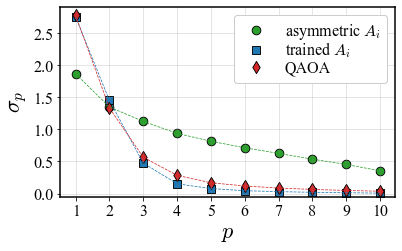

In [6]:
n = 6
n_instances = 100
p_max = 10

pp = np.array(range(1,p_max+1))


S_ion_avg, S_ion_std = get_avg_singular(n,p_max,n_instances,path='data_mod_4/',fdata='q_lw_')
S_qaoa_avg, S_qaoa_std = get_avg_singular_qaoa(n,p_max,n_instances)
S_asym_avg, S_asym_std = get_avg_singular(n,p_max,n_instances,path='data_mod_4/',fdata='q_lw_asym_')

data_asym = np.zeros((p_max,3))
data_asym[:,0] = pp
data_asym[:,1] = S_asym_avg
data_asym[:,2] = S_asym_std

data_ion = np.zeros((p_max,3))
data_ion[:,0] = pp
data_ion[:,1] = S_ion_avg
data_ion[:,2] = S_ion_std

data_qaoa = np.zeros((p_max,3))
data_qaoa[:,0] = pp
data_qaoa[:,1] = S_qaoa_avg
data_qaoa[:,2] = S_qaoa_std

data_sets = [data_asym, data_ion, data_qaoa]
labels = ['asymmetric $A_i$', 'trained $A_i$', 'QAOA']
markers = ['o', 's', 'd', 'v', 'p', 'H']
colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:orange', 'tab:brown', 'tab:cyan']

plot_data(data_sets,labels,markers,colors,ylabel='$\sigma_{p}$',ymin=-0.05,ncol=1,loc=0,log=0)

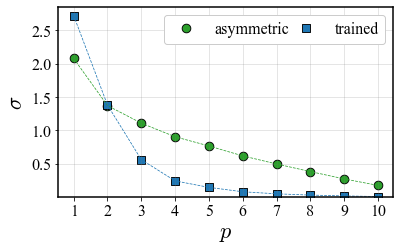

In [4]:
n = 5
n_instances = 100
p_max = 10

pp = np.array(range(1,p_max+1))


S_asym_avg, S_asym_std = get_avg_singular(n,p_max,n_instances,path='data_mod_4/',fdata='q_lw_asym_')
S_trained_avg, S_trained_std = get_avg_singular(n,p_max,n_instances,path='data_mod_4/',fdata='q_lw_')

data_asym = np.zeros((p_max,2))
data_asym[:,0] = pp
data_asym[:,1] = S_asym_avg

data_trained = np.zeros((p_max,2))
data_trained[:,0] = pp
data_trained[:,1] = S_trained_avg

data_sets = [data_asym, data_trained]
labels = ['asymmetric', 'trained']
markers = ['o', 's']
colors = ['tab:green', 'tab:blue']

data_sets = [data_asym,data_trained]

plot_data(data_sets,labels,markers,colors,ylabel='$\sigma$',ymin=5e-3,ncol=2,loc=0,log=0)

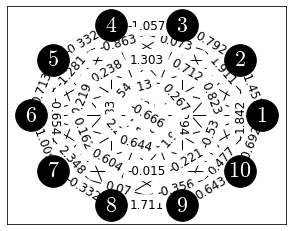

Ground state: -7.342540756468401
Energy gap: 0.11105058853331862
Max excited state energy: 5.375525244747216


In [9]:
# number of qubits
n = 10
n_edges = n*(n-1)//2

# ions chain parameters
nu_rad = 1e6
nu_ax = 0.15e6
mu = 2*np.pi*(nu_rad + 10e3) # in Hz
Omega_max = 2*np.pi*30e3     # in Hz

coupling_mat = radial_coupling_matrix(n, nu_rad, nu_ax, mu, Omega_max) # in kHz

# read data
index = 2 # data instance id from 1 to 100
# generate random Sherrington-Kirkpatrick instance
np.random.seed(100*index)
n_edges = n*(n-1)//2
weights = list(np.random.normal(size=n_edges))

G = get_weighted_graph(n,list(np.round(weights,3)))
pos = nx.circular_layout(G)

draw_graph(G, pos)

H2 = get_hamiltonian(n,weights)
gs = np.min(H2)
emax = np.max(H2)

spectrum = np.unique(np.sort(H2))

gap = spectrum[1] - spectrum[0]
print("Ground state:", gs)
print("Energy gap:", gap)
print("Max excited state energy:", emax)

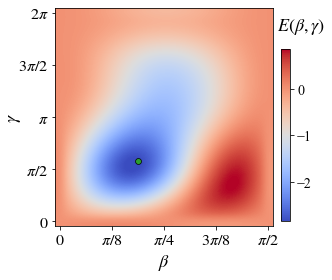

-2.857774972365073 0.8737925850990667 [-0.642693 -0.53498   0.447143 -0.420812 -0.451741 -0.511715 -0.44624
  0.567437]


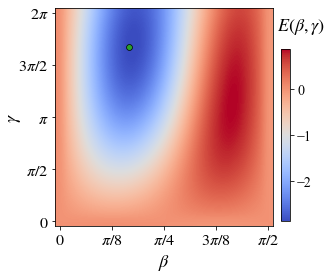

28125


In [37]:
path = f'example_data/'
fname = f'{n}q_{index}.txt'
fname1 = path + fname

# read simulation parameters
n_iter = 50
max_restarts = 10
eps = 1e-3
tol_lvl = 0.5

np.random.seed(123*index)
training(path,fname,n,weights,coupling_mat,n_iter,tol_lvl,max_restarts,eps)


A = np.genfromtxt(fname1,skip_header=2)
H1 = ion_native_hamiltonian(n,A,coupling_mat)
Q = QAOA(1,H1,H2)
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(np.min(landscape),np.max(landscape),A)

A_rescaled, alpha, nfev = rescale_contr_params(n,A,H2,coupling_mat,k=25,eps=0.05)
H1_rescaled = ion_native_hamiltonian(n,A_rescaled,coupling_mat)
Q = QAOA(1,H1_rescaled,H2)
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(nfev)

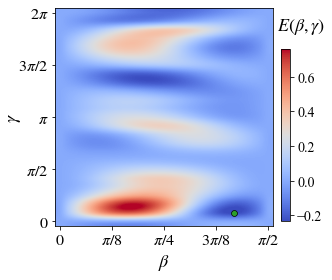

-0.2355694571563065


In [56]:
A_asym = np.ones(n)
A_asym[0] = -0.3
H1 = ion_native_hamiltonian(n,A_asym,coupling_mat)
Q = QAOA(1,H1,H2)
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(np.min(landscape))

In [57]:
p_max = 10

np.random.seed(12311)

H1 = ion_native_hamiltonian(n,A_rescaled,coupling_mat)
energies, angles, ovlp, r, nfev, exe_time = run_QAOA(H1,H2,p_max,method=0,n_runs=0)

pp = np.array(range(1,p_max+1))

data_trained = np.zeros((p_max,2))
data_trained[:,0] = pp
data_trained[:,1] = 1 - r

np.random.seed(12551)

H1 = ion_native_hamiltonian(n,A_asym,coupling_mat)
energies1, angles1, ovlp1, r1, nfev1, exe_time1 = run_QAOA(H1,H2,p_max,method=0,n_runs=0)

data_asym = np.zeros((p_max,2))
data_asym[:,0] = pp
data_asym[:,1] = 1 - r1

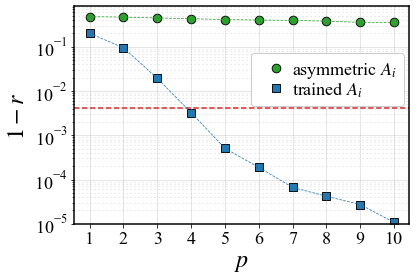

In [58]:
data_sets = [data_asym, data_trained]
labels = ['asymmetric $A_i$', 'trained $A_i$']
markers = ['o', 's']
colors = ['tab:green', 'tab:blue']

plot_energies_log(data_sets,labels,markers,colors,-gap/2.0/(gs - emax),1e-5)

In [59]:
def get_singular(n,p_max,A,coupling_mat,H2,angles):
    
    H1 = ion_native_hamiltonian(n,A,coupling_mat)
    Q = QAOA(1,H1,H2)
    
    sv_matrix = np.zeros((p_max,2**n),dtype=np.complex128)

    for p in range(p_max):
    
        Q.p = p + 1 
        angles_p = np.concatenate([angles[:p],angles[p_max:p_max+p]])
        sv_matrix[p,:] = Q.qaoa_ansatz(angles_p).reshape(-1)
    
    U, S, Vh = np.linalg.svd(sv_matrix, full_matrices=False)
    
    return S

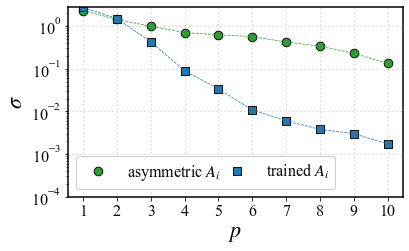

In [60]:
S_asym = get_singular(n,p_max,A_asym,coupling_mat,H2,angles1)
S_trained = get_singular(n,p_max,A_rescaled,coupling_mat,H2,angles)

data_asym[:,1] = S_asym
data_trained[:,1] = S_trained

data_sets = [data_asym,data_trained]

plot_data(data_sets,labels,markers,colors,ylabel='$\sigma$',ymin=1e-4,ncol=2,loc=0)